
# INTERN PORTFOLIO READINESS SCORER
# COMPLETE MACHINE LEARNING PIPELINE

# 1. IMPORT LIBRARIES


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')


# 2. LOAD DATASET


In [28]:
df = pd.read_excel("final_intern_readiness_dataset.xlsx")

df = df.copy()

# 3. BASIC DATASET INFORMATION

In [29]:

print("\n================ DATASET SHAPE ================")
print(df.shape)

print("\n================ FIRST 5 ROWS ================")
print(df.head())

print("\n================ COLUMN NAMES ================")
print(df.columns)

print("\n================ MISSING VALUES ================")
print(df.isnull().sum())

print("\n================ DATA TYPES ================")
print(df.dtypes)

print("\n================ TARGET DISTRIBUTION ================")
print(df['Employability_Label'].value_counts())



================ DATASET SHAPE ================
(1555, 11)

================ FIRST 5 ROWS ================
             name                  role  no_of_projects  business_relevance  \
0  The Algorithms  Full-Stack Developer              44               10.00   
1         GPU.net       Software Intern              18                9.98   
2  Shradha Khapra       Software Intern              24               10.00   
3           N17R0  Full-Stack Developer              19               10.00   
4    vivekweb2013       Software Intern              25                7.40   

   presentation_score  documentation_quality  \
0                10.0                   5.62   
1                 1.5                   9.66   
2                 5.5                  10.00   
3                 5.5                   8.81   
4                 3.0                   8.61   

                                     tools_used  avg_project_score  \
0                           Mojo, HTML, Fortran           

# 4. HANDLE MISSING VALUES

In [30]:

for col in df.columns:

    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')

    else:
        df[col] = df[col].fillna(df[col].median())

# 5. FEATURE ENGINEERING

In [31]:
df['Tool_Count'] = df['tools_used'].apply(
    lambda x: len(str(x).split(','))
)

df['Projects_Per_Tool'] = (
    df['no_of_projects'] / (df['Tool_Count'] + 1)
)

df['Documentation_Per_Project'] = (
    df['documentation_quality'] / (df['no_of_projects'] + 1)
)

df['Business_Impact_Per_Project'] = (
    df['business_relevance'] / (df['no_of_projects'] + 1)
)

df['Combined_Quality_Score'] = (
    df['avg_project_score'] +
    df['documentation_quality'] +
    df['presentation_score']
) / 3

df['Consistency_Index'] = (
    df['task_consistency'] * 0.7 +
    df['business_relevance'] * 0.3
)

#  ENCODE TARGET VARIABLE

In [32]:
label_encoder = LabelEncoder()

df['Target_Encoded'] = label_encoder.fit_transform(
    df['Employability_Label']
)

# 6. REMOVE DATA LEAKAGE COLUMNS

In [33]:
# These columns directly reveal the target
# and should NOT be used for training

remove_cols = [
    'Readiness_Score',
    'Employability_Label',
    'Target_Encoded',
    'name'
]

existing_remove_cols = [
    col for col in remove_cols if col in df.columns
]

X = df.drop(columns=existing_remove_cols)

y = df['Target_Encoded']



# 8. IDENTIFY NUMERIC AND CATEGORICAL COLUMNS

In [34]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object']
).columns

print("\n================ NUMERIC FEATURES ================")
print(numeric_features)

print("\n================ CATEGORICAL FEATURES ================")
print(categorical_features)


================ NUMERIC FEATURES ================
Index(['no_of_projects', 'business_relevance', 'presentation_score',
       'documentation_quality', 'avg_project_score', 'task_consistency',
       'Tool_Count', 'Projects_Per_Tool', 'Documentation_Per_Project',
       'Business_Impact_Per_Project', 'Combined_Quality_Score',
       'Consistency_Index'],
      dtype='object')

================ CATEGORICAL FEATURES ================
Index(['role', 'tools_used'], dtype='object')


# 9. PREPROCESSING PIPELINE

In [35]:
# ------------------------------------------------------------
# Numerical preprocessing
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# ------------------------------------------------------------
# Combine preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)


# 10. TRAIN TEST SPLIT

In [36]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n================ TRAIN SHAPE ================")
print(X_train.shape)

print("\n================ TEST SHAPE ================")
print(X_test.shape)



================ TRAIN SHAPE ================
(1244, 14)

================ TEST SHAPE ================
(311, 14)


# 11. CREATE MACHINE LEARNING MODELS

In [37]:
# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=3000,
                class_weight='balanced',
                penalty='l2',
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            DecisionTreeClassifier(
                class_weight='balanced',
                max_depth=8,
                min_samples_split=8,
                min_samples_leaf=4,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                class_weight='balanced',
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=42
            )
        )
    ]
)


# 12. STORE MODELS

In [38]:
models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model
}

# 13. TRAIN AND EVALUATE MODELS


TRAINING MODEL: Logistic Regression

Train Accuracy: 0.9944
Test Accuracy: 0.9614
Balanced Accuracy: 0.9632
Macro F1 Score: 0.9516
Cross Validation Balanced Accuracy: 0.9691
Accuracy Gap: 0.0330
Good Generalization

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

     Almost Ready       0.94      0.96      0.95       112
        Job Ready       0.99      0.96      0.98       165
Needs Improvement       0.89      0.97      0.93        34

         accuracy                           0.96       311
        macro avg       0.94      0.96      0.95       311
     weighted avg       0.96      0.96      0.96       311



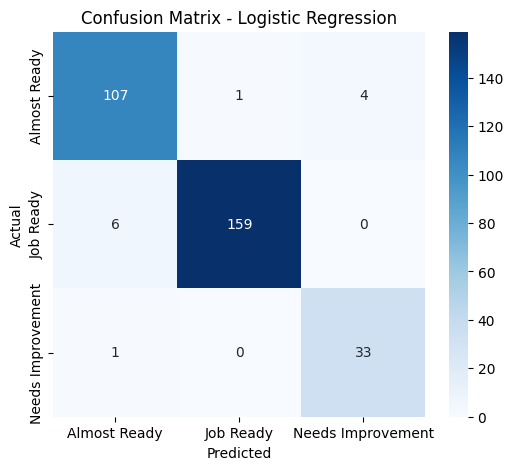


TRAINING MODEL: Decision Tree

Train Accuracy: 0.9839
Test Accuracy: 0.9421
Balanced Accuracy: 0.9180
Macro F1 Score: 0.9266
Cross Validation Balanced Accuracy: 0.9277
Accuracy Gap: 0.0418
Good Generalization

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

     Almost Ready       0.91      0.94      0.92       112
        Job Ready       0.97      0.96      0.97       165
Needs Improvement       0.94      0.85      0.89        34

         accuracy                           0.94       311
        macro avg       0.94      0.92      0.93       311
     weighted avg       0.94      0.94      0.94       311



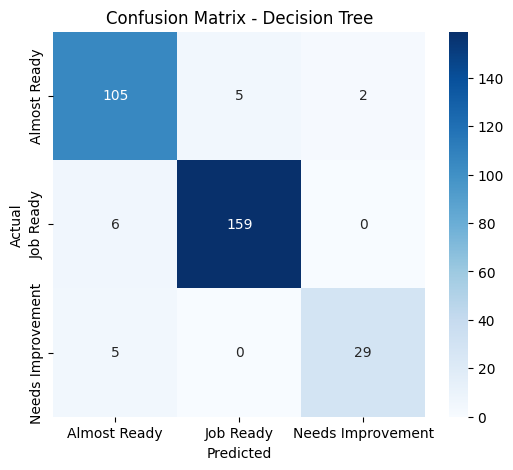


TRAINING MODEL: Random Forest

Train Accuracy: 1.0000
Test Accuracy: 0.9486
Balanced Accuracy: 0.9152
Macro F1 Score: 0.9305
Cross Validation Balanced Accuracy: 0.9376
Accuracy Gap: 0.0514
Good Generalization

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

     Almost Ready       0.91      0.95      0.93       112
        Job Ready       0.97      0.98      0.97       165
Needs Improvement       0.97      0.82      0.89        34

         accuracy                           0.95       311
        macro avg       0.95      0.92      0.93       311
     weighted avg       0.95      0.95      0.95       311



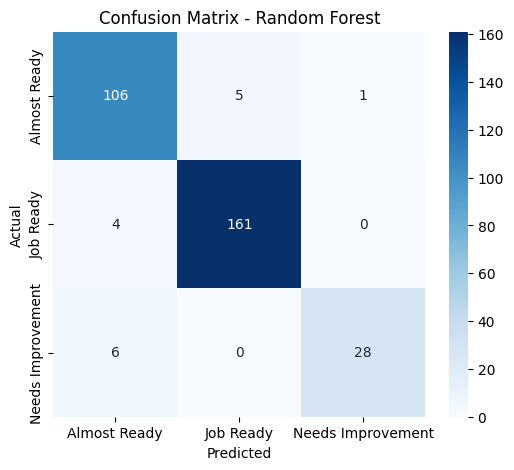

In [39]:
results = {}

for name, model in models.items():

    print("\n====================================================")
    print(f"TRAINING MODEL: {name}")
    print("====================================================")

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    balanced_acc = balanced_accuracy_score(
        y_test,
        test_pred
    )

    macro_f1 = f1_score(
        y_test,
        test_pred,
        average='macro'
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='balanced_accuracy'
    )

    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Balanced Accuracy': balanced_acc,
        'Macro F1 Score': macro_f1,
        'CV Balanced Accuracy': cv_scores.mean()
    }

    print(f"\nTrain Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Macro F1 Score: {macro_f1:.4f}")
    print(f"Cross Validation Balanced Accuracy: {cv_scores.mean():.4f}")

    gap = train_acc - test_acc

    print(f"Accuracy Gap: {gap:.4f}")

    if gap > 0.10:
        print("Possible Overfitting Detected")
    else:
        print("Good Generalization")

    print("\nCLASSIFICATION REPORT")

    print(
        classification_report(
            y_test,
            test_pred,
            target_names=label_encoder.classes_
        )
    )

    cm = confusion_matrix(y_test, test_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

# 14. MODEL COMPARISON

In [40]:
results_df = pd.DataFrame(results).T

print("\n====================================================")
print("FINAL MODEL COMPARISON")
print("====================================================")

print(results_df)



FINAL MODEL COMPARISON
                     Train Accuracy  Test Accuracy  Balanced Accuracy  \
Logistic Regression        0.994373       0.961415           0.963194   
Decision Tree              0.983923       0.942122           0.918026   
Random Forest              1.000000       0.948553           0.915239   

                     Macro F1 Score  CV Balanced Accuracy  
Logistic Regression        0.951647              0.969075  
Decision Tree              0.926642              0.927745  
Random Forest              0.930508              0.937575  


# 15. VISUALIZE MODEL PERFORMANCE

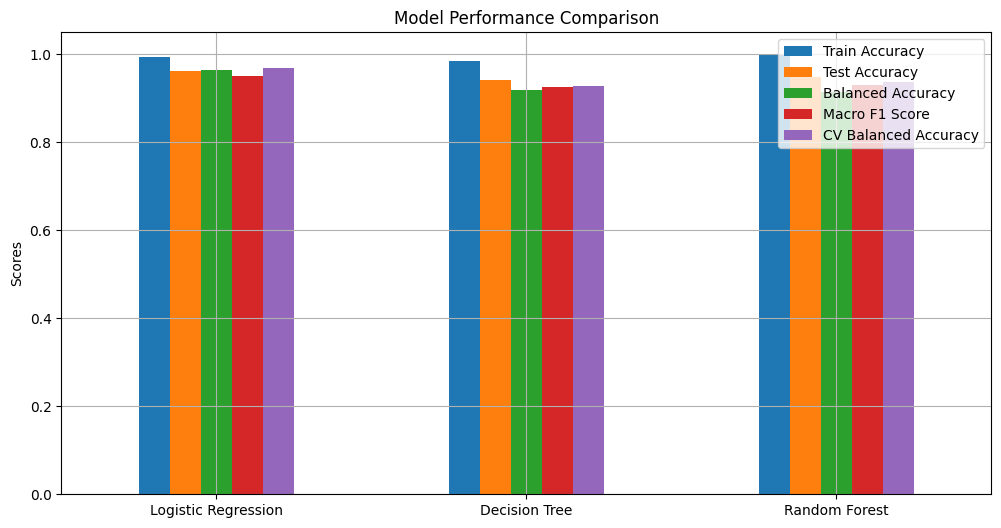

In [41]:
results_df.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Scores')
plt.xticks(rotation=0)
plt.grid(True)

plt.show()



# 16. FIND BEST MODEL

In [42]:
best_model_name = results_df[
    'CV Balanced Accuracy'
].idxmax()

print("\n====================================================")
print(f"BEST MODEL: {best_model_name}")
print("====================================================")

best_model = models[best_model_name]


BEST MODEL: Logistic Regression


# 17. FEATURE IMPORTANCE (RANDOM FOREST)

In [43]:
rf_model = random_forest_model

rf_model.fit(X_train, y_train)

encoded_feature_names = rf_model.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'encoder'
].get_feature_names_out(categorical_features)

all_feature_names = (
    list(numeric_features) +
    list(encoded_feature_names)
)

importances = rf_model.named_steps[
    'classifier'
].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n====================================================")
print("TOP 15 IMPORTANT FEATURES")
print("====================================================")

print(importance_df.head(15))


TOP 15 IMPORTANT FEATURES
                         Feature  Importance
1             business_relevance    0.175936
11             Consistency_Index    0.160728
4              avg_project_score    0.147168
5               task_consistency    0.079204
9    Business_Impact_Per_Project    0.064491
10        Combined_Quality_Score    0.063282
0                 no_of_projects    0.051738
7              Projects_Per_Tool    0.041449
8      Documentation_Per_Project    0.037987
3          documentation_quality    0.027069
2             presentation_score    0.024703
14        role_Frontend Engineer    0.016550
15     role_Full-Stack Developer    0.009939
6                     Tool_Count    0.007786
170        tools_used_JavaScript    0.003063


# 18. PLOT TOP FEATURES

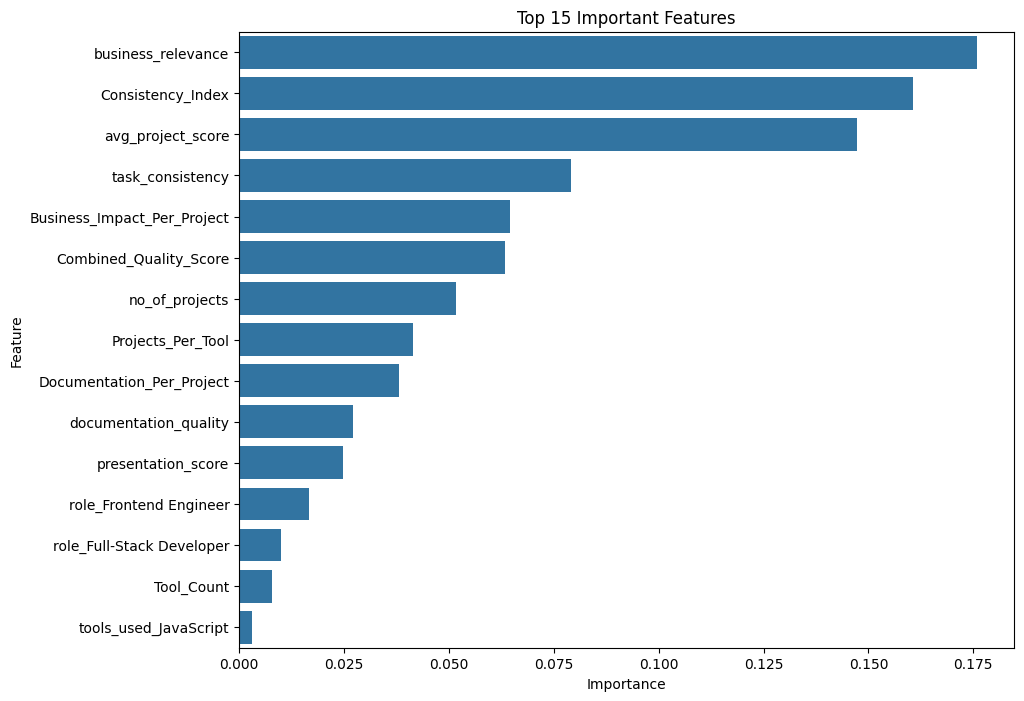

In [44]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15)
)

plt.title('Top 15 Important Features')

plt.show()

# 19. GENERATE READINESS SCORE (0-100)

In [45]:
# Predict class probabilities

probabilities = best_model.predict_proba(X_test)

readiness_scores = []

for prob in probabilities:

    # Weighted scoring system

    score = (
        prob[0] * 30 +
        prob[1] * 70 +
        prob[2] * 100
    )

    readiness_scores.append(round(score, 2))

# ------------------------------------------------------------
# Create prediction dataframe
# ------------------------------------------------------------

prediction_df = X_test.copy()

prediction_df['Predicted_Class'] = best_model.predict(X_test)

prediction_df['Readiness_Score'] = readiness_scores

prediction_df['Predicted_Category'] = label_encoder.inverse_transform(
    prediction_df['Predicted_Class']
)

print("\n====================================================")
print("READINESS SCORE OUTPUT")
print("====================================================")

print(
    prediction_df[[
        'Readiness_Score',
        'Predicted_Category'
    ]].head(10)
)


READINESS SCORE OUTPUT
      Readiness_Score Predicted_Category
675             65.19          Job Ready
165             70.00          Job Ready
932             69.82          Job Ready
667             30.27       Almost Ready
827             30.06       Almost Ready
1473            55.06          Job Ready
804             30.18       Almost Ready
978             69.99          Job Ready
1321            70.00          Job Ready
1057            99.68  Needs Improvement


# 20. SAVE BEST MODEL

In [46]:

joblib.dump(
    best_model,
    'best_intern_readiness_model.pkl'
)

print("\n====================================================")
print("MODEL SAVED SUCCESSFULLY")
print("====================================================")


MODEL SAVED SUCCESSFULLY


# Checking the leakage

In [21]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

print(corr['Target_Encoded'].sort_values(ascending=False))

Target_Encoded                 1.000000
Documentation_Per_Project      0.137677
Tool_Count                     0.028742
Combined_Quality_Score         0.019712
presentation_score             0.017857
documentation_quality          0.016805
avg_project_score              0.011667
business_relevance            -0.004357
Business_Impact_Per_Project   -0.045619
Readiness_Score               -0.066017
no_of_projects                -0.082945
Projects_Per_Tool             -0.090996
Consistency_Index             -0.152203
task_consistency              -0.203535
Name: Target_Encoded, dtype: float64


In [22]:
print(df['Employability_Label'].value_counts())

Employability_Label
Job Ready            825
Almost Ready         562
Needs Improvement    168
Name: count, dtype: int64


In [23]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, test_pred)

print(balanced_acc)

0.6695484254307784


# Although the model achieved high overall accuracy, the dataset was imbalanced across employability categories. Therefore, balanced accuracy and class-wise performance were also evaluated. To reduce majority-class bias, class balancing techniques such as class weighting were incorporated into the models.

# Final conclusion
Initially, the dataset had class imbalance issues, which inflated standard accuracy metrics. To solve this, balanced accuracy, macro F1 score, and class-weight balancing techniques were implemented. After applying these improvements, the Logistic Regression model achieved 96.32% balanced accuracy with strong cross-validation performance, indicating good generalization and stable prediction capability without significant overfitting or data leakage.
